Begin with an image:

In [16]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 

For implementation we begin with classical gradient flow on $R$. 
We have 
$$
        \text{I}(\rho) = \rho_\text{I}(x,z) = \int_0^1\rho(x,y,z)dy \\
        \text{II}(\rho) = \rho_\text{II}(y,z) = \int_0^1 \rho(x,y,z)dx
$$

$$
        \mathcal{E} = \frac{1}{2}||\text{I}(R)-\rho_\text{I}||_2^2 + \frac{1}{2}||\text{II}(R)-\rho_\text{II}||_2^2 + \text{regularisation}
$$

$$
        R = \arg \min \mathcal{E}
$$

Suppose $R = R[i,j,k]$ is a 3D array.

In [17]:
# image parameters
g = 1
t = 5

# image paths
xz_path = (f"../../data/synthetic/images/gen_{g:02d}/plant_gen{g:02d}_t{t:02d}_xz.png")

yz_path = (f"../../data/synthetic/images/gen_{g:02d}/plant_gen{g:02d}_t{t:02d}_yz.png")

# load images
img_xz = cv2.imread(xz_path, cv2.IMREAD_GRAYSCALE)
img_yz = cv2.imread(yz_path, cv2.IMREAD_GRAYSCALE)

if img_xz is None:
    raise FileNotFoundError(xz_path)

if img_yz is None:
    raise FileNotFoundError(yz_path)

# convert to [0,1]
# rho_xz and rho_yz are the probability distributions along the xz and yz planes
# (x,z) and (y,z) respectively. The .T is to transpose the arrays so that the z-axis is the first axis.
rho_xz = (img_xz > 0).astype(np.float32).T
rho_yz = (img_yz > 0).astype(np.float32).T

# optional denoising / uncertainty model
# rho_xz = cv2.GaussianBlur(rho_xz, (0, 0), sigmaX=2)
# rho_yz = cv2.GaussianBlur(rho_yz, (0, 0), sigmaX=2)

# construct R0
R0 = rho_xz[:, None, :] * rho_yz[None, :, :]

print("rho_xz shape:", rho_xz.shape)
print("rho_yz shape:", rho_yz.shape)
print("R0 shape:", R0.shape)
print("R0 mass:", R0.sum())

rho_xz shape: (512, 512)
rho_yz shape: (512, 512)
R0 shape: (512, 512, 512)
R0 mass: 2969.0


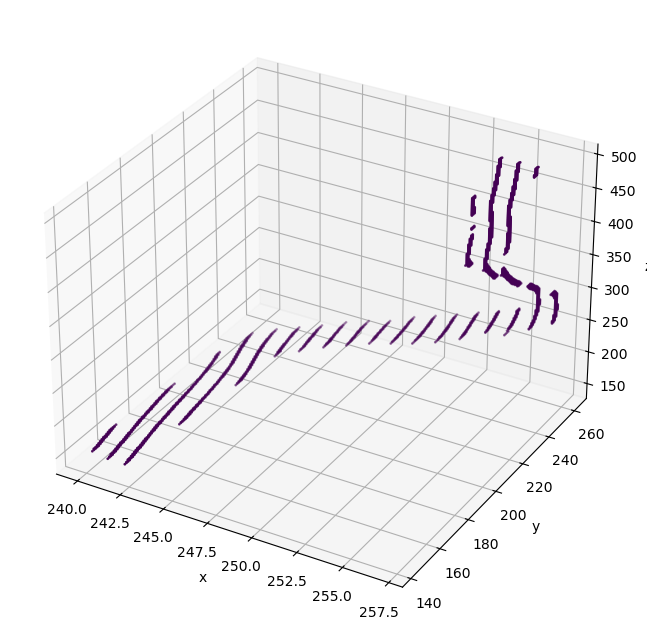

In [18]:
threshold = 0

x, y, z = np.where(R0 > threshold)

fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(x, y, z, s=1, c=R0[x,y,z], cmap='viridis')

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')

plt.show()

[np.float32(5005.4995), np.float32(4503.0376), np.float32(4051.4187), np.float32(3645.2239), np.float32(3279.9639), np.float32(2951.4893), np.float32(2656.0283), np.float32(2390.2324), np.float32(2151.1023), np.float32(1936.0055), np.float32(1742.4382), np.float32(1568.259), np.float32(1411.5526), np.float32(1270.522), np.float32(1143.6116), np.float32(1029.3804), np.float32(926.60376), np.float32(834.09576), np.float32(750.8308), np.float32(675.8884), np.float32(608.4384), np.float32(547.7329), np.float32(493.0791), np.float32(443.8873), np.float32(399.62103), np.float32(359.76617), np.float32(323.9026), np.float32(291.60388), np.float32(262.53494), np.float32(236.3719), np.float32(212.826), np.float32(191.61241), np.float32(172.53423), np.float32(155.35333), np.float32(139.88594), np.float32(125.96417), np.float32(113.43206), np.float32(102.150795), np.float32(91.9939), np.float32(82.85321), np.float32(74.62369), np.float32(67.21433), np.float32(60.545765), np.float32(54.53894), np.f

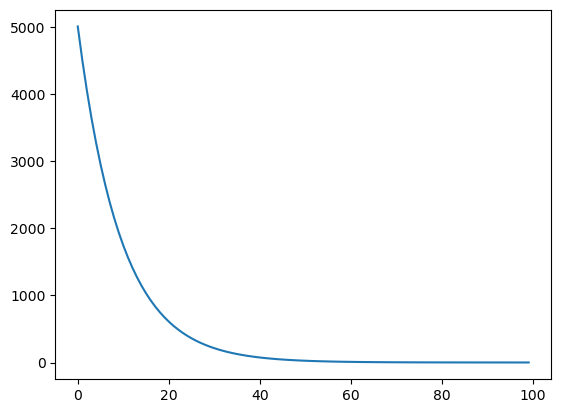

In [19]:
Nx, Ny, Nz = R0.shape
dt = 1e-4
num_steps = 100
Energy = []
R = R0.copy()

for n in range(num_steps):

    # Forward projections
    I_R  = np.sum(R, axis=1)   # integrate over y
    II_R = np.sum(R, axis=0)   # integrate over x

    # Residuals
    e_xz = I_R  - rho_xz
    e_yz = II_R - rho_yz

    # Adjoint operators
    grad_xz = np.repeat(e_xz[:, None, :], Ny, axis=1)

    grad_yz = np.repeat(e_yz[None, :, :], Nx, axis=0)

    # Functional derivative
    grad = grad_xz + grad_yz

    # Gradient flow step
    R -= dt * grad

    E = (0.5 * np.linalg.norm(e_xz)**2 + 0.5 * np.linalg.norm(e_yz)**2)
    Energy.append(E)

plt.plot(Energy)
print(Energy)

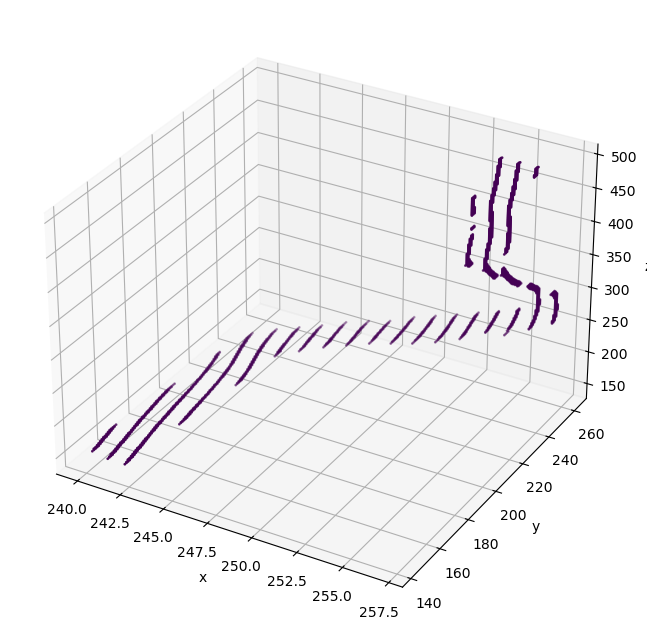

In [20]:
threshold = 0

x, y, z = np.where(R0 > threshold)

fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(x, y, z, s=1, c=R0[x,y,z], cmap='viridis')

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')

plt.show()

In [21]:
curve = []

Nx, Ny, Nz = R0.shape
X, Y = np.meshgrid(np.arange(Nx), np.arange(Ny), indexing='ij')

for z in range(Nz):
    P = R0[:, :, z]

    mass = np.sum(P)

    if mass < 1e-12:
        continue

    x = float(np.sum(X * P) / mass)
    y = float(np.sum(Y * P) / mass)

    curve.append([x, y, z])

curve = np.array(curve)

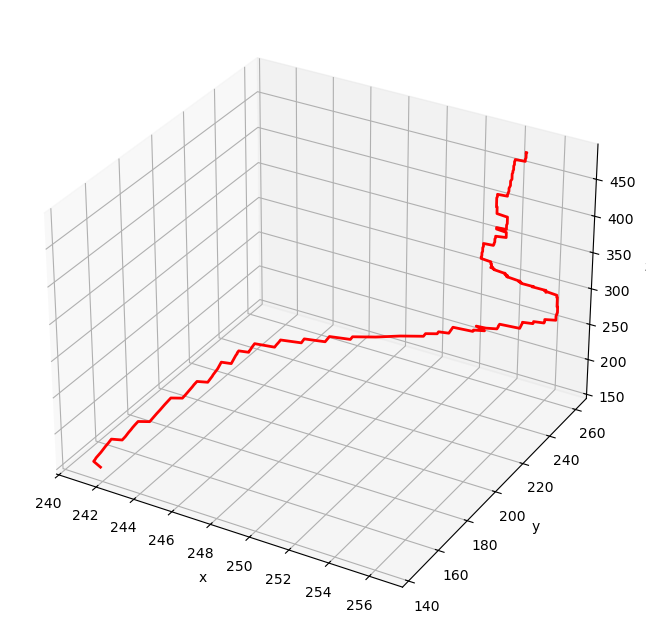

In [22]:
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection='3d')

ax.plot(
    curve[:,0],
    curve[:,1],
    curve[:,2],
    'r-',
    linewidth=2
)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")

plt.show()

In [42]:
camera_params_path = f"../../data/synthetic/images/gen_{g:02d}/camera_params.csv"

camera_params = pd.read_csv(camera_params_path)

scale = camera_params['scale'].values[0]
x_offset = camera_params['x_offset'].values[0]
z_offset = camera_params['z_offset'].values[0]

Nx, Ny, Nz = R0.shape

x_phys = (np.arange(Nx) - x_offset) / scale
y_phys = (np.arange(Ny) - x_offset) / scale
z_phys = ((Nz - 1) - np.arange(Nz) - z_offset) / scale

curve_phys = np.column_stack([
    x_phys[curve[:,0].astype(int)],
    y_phys[curve[:,1].astype(int)],
    z_phys[curve[:,2].astype(int)]
])

curve_phys = np.flipud (curve_phys)

# Then recenter the curve to be at origin 
x0, y0, z0 = curve_phys[0]
curve_phys -= np.array([x0, y0, z0])

In [43]:
true_curve_path = f"../../data/synthetic/images/true_curve.csv"

df = pd.read_csv(true_curve_path)

df = df[(df["gen"] == g) & (df["time"] == float(t))]

true_curve = df[["x", "y", "z"]].values

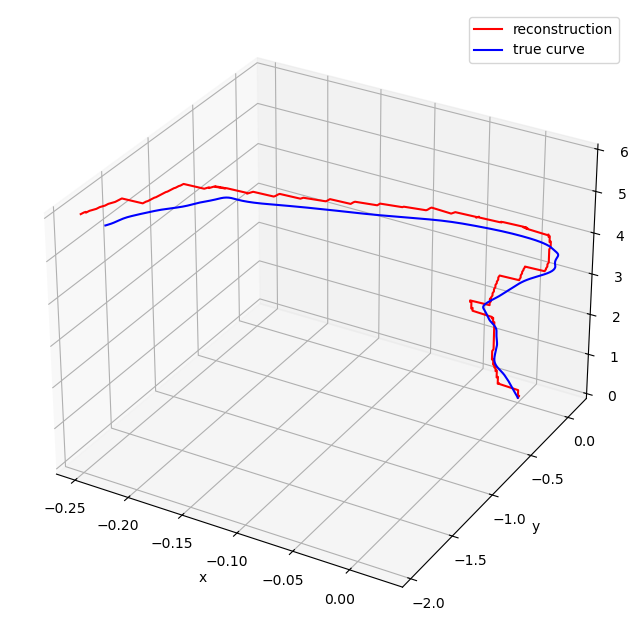

In [44]:
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection='3d')

ax.plot(
    curve_phys[:,0],
    curve_phys[:,1],
    curve_phys[:,2],
    'r-',
    label = "reconstruction"
)

ax.plot(
    true_curve[:,0],
    true_curve[:,1],
    true_curve[:,2],
    'b-',
    label = "true curve"
)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.legend()

plt.show()

In [45]:
def resample_curve(curve, n_points=100):
    """
    curve: (N,3)
    returns: (n_points,3) equally spaced in arc length
    """

    seg_lengths = np.linalg.norm(
        np.diff(curve, axis=0),
        axis=1
    )

    s = np.concatenate([[0], np.cumsum(seg_lengths)])

    s_uniform = np.linspace(0, s[-1], n_points)

    x = np.interp(s_uniform, s, curve[:,0])
    y = np.interp(s_uniform, s, curve[:,1])
    z = np.interp(s_uniform, s, curve[:,2])

    return np.column_stack([x,y,z])

In [46]:
true100 = resample_curve(true_curve, 100)
recon100 = resample_curve(curve_phys, 100)

errors = np.linalg.norm(recon100 - true100,axis=1)

rmse = np.sqrt(np.mean(errors**2))
mean_err = np.mean(errors)
max_err = np.max(errors)

print("RMSE:", rmse)
print("Mean:", mean_err)
print("Max :", max_err)

L_true = np.sum(
    np.linalg.norm(
        np.diff(true_curve, axis=0),
        axis=1
    )
)

relative_rmse = rmse / L_true
print("Relative RMSE:", relative_rmse)

RMSE: 0.17110817635021508
Mean: 0.15289741478512686
Max : 0.289273647365208
Relative RMSE: 0.025661900940573697
